# Capítulo 4 — Variables de entrada y variable objetivo

En el cuaderno anterior recorrimos un primer flujo completo de Machine Learning. Ahora vamos a detenernos en una decisión que allí apareció brevemente: separar la información que recibe el modelo de la respuesta que queremos predecir.

Trabajaremos con un pequeño conjunto de datos de clientes. El objetivo será organizar correctamente `X` e `y`, reconocer variables numéricas y categóricas, y detectar columnas que no deberían usarse porque contienen información posterior al abandono.

## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- distinguir las variables de entrada de la variable objetivo;
- construir `X` e `y` a partir de un DataFrame;
- reconocer variables numéricas, categóricas e identificadores;
- analizar si una variable podría aportar información útil;
- revisar cuándo está disponible cada dato;
- detectar un caso claro de fuga de datos.

## 1. Importar las librerías

Usaremos `pandas` para organizar y analizar los datos, y `matplotlib` para crear dos visualizaciones sencillas. En este cuaderno no entrenaremos un modelo: el foco estará en decidir qué información sería válido entregarle.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Conocer el problema y los datos

Supongamos que una empresa de servicios quiere anticipar qué clientes abandonarán durante el mes siguiente. La predicción se realizaría al finalizar el mes actual.

El siguiente dataset es pequeño y fue construido con fines didácticos. Cada fila representa un cliente. Algunas columnas describen su situación antes de la predicción y otras fueron registradas después de conocerse el abandono. Estas últimas nos permitirán estudiar un error frecuente.

In [2]:
datos = {
    "cliente_id": list(range(1001, 1025)),
    "antiguedad_meses": [36, 4, 18, 2, 48, 9, 27, 6, 40, 14, 3, 31,
                           22, 7, 55, 11, 25, 5, 43, 16, 8, 34, 20, 12],
    "uso_semanal_horas": [9.2, 1.4, 6.8, 0.8, 10.5, 3.1, 7.6, 2.0, 8.9, 4.8,
                            1.1, 7.9, 6.2, 2.4, 11.0, 4.1, 7.0, 1.7, 9.8, 5.2,
                            2.8, 8.1, 6.0, 3.6],
    "reclamos_ultimos_3_meses": [0, 3, 1, 4, 0, 2, 1, 3, 0, 1, 4, 0,
                                   1, 3, 0, 2, 1, 4, 0, 1, 2, 0, 1, 2],
    "dias_desde_ultimo_acceso": [2, 24, 5, 31, 1, 15, 4, 22, 2, 8, 28, 3,
                                   6, 20, 1, 12, 5, 26, 2, 7, 18, 3, 6, 14],
    "tipo_plan": ["Premium", "Básico", "Estándar", "Básico", "Premium", "Premium",
                  "Estándar", "Básico", "Premium", "Básico", "Básico", "Premium",
                  "Básico", "Básico", "Premium", "Estándar", "Estándar", "Básico",
                  "Premium", "Estándar", "Básico", "Premium", "Estándar", "Básico"],
    "pago_automatico": ["Sí", "No", "Sí", "No", "Sí", "No", "Sí", "No",
                         "Sí", "Sí", "No", "Sí", "Sí", "No", "Sí", "No",
                         "Sí", "No", "Sí", "Sí", "No", "Sí", "Sí", "No"],
    "canal_preferido": ["App", "Teléfono", "Web", "Teléfono", "App", "Web",
                         "App", "Teléfono", "Web", "App", "Teléfono", "App",
                         "Web", "Teléfono", "App", "Web", "App", "Teléfono",
                         "Web", "App", "Web", "App", "Web", "Teléfono"],
    "abandono_proximo_mes": ["No", "Sí", "No", "Sí", "No", "Sí", "No", "Sí",
                              "No", "No", "Sí", "No", "No", "Sí", "No", "Sí",
                              "No", "Sí", "No", "No", "Sí", "No", "No", "Sí"],
    "fecha_baja": [None, "2026-05-08", None, "2026-05-03", None, "2026-05-17",
                    None, "2026-05-11", None, None, "2026-05-06", None,
                    None, "2026-05-20", None, "2026-05-14", None, "2026-05-09",
                    None, None, "2026-05-23", None, None, "2026-05-28"],
    "motivo_baja": [None, "Precio", None, "Falta de uso", None, "Problemas técnicos",
                     None, "Precio", None, None, "Falta de uso", None,
                     None, "Precio", None, "Problemas técnicos", None, "Falta de uso",
                     None, None, "Precio", None, None, "Falta de uso"],
}

df = pd.DataFrame(datos)
df.head(8)

,cliente_id,antiguedad_meses,uso_semanal_horas,reclamos_ultimos_3_meses,dias_desde_ultimo_acceso,tipo_plan,pago_automatico,canal_preferido,abandono_proximo_mes,fecha_baja,motivo_baja
0,1001,36,9.2,0,2,Premium,Sí,App,No,None,None
1,1002,4,1.4,3,24,Básico,No,Teléfono,Sí,2026-05-08,Precio
2,1003,18,6.8,1,5,Estándar,Sí,Web,No,None,None
3,1004,2,0.8,4,31,Básico,No,Teléfono,Sí,2026-05-03,Falta de uso
4,1005,48,10.5,0,1,Premium,Sí,App,No,None,None
5,1006,9,3.1,2,15,Premium,No,Web,Sí,2026-05-17,Problemas técnicos
6,1007,27,7.6,1,4,Estándar,Sí,App,No,None,None
7,1008,6,2.0,3,22,Básico,No,Teléfono,Sí,2026-05-11,Precio


Las primeras filas muestran información de uso, relación comercial y contacto. También aparecen `fecha_baja` y `motivo_baja`, que solo tienen valores cuando el cliente ya abandonó. Que una columna esté disponible en la tabla histórica no significa que sea una entrada válida para una predicción.

Antes de seleccionar columnas, revisemos la estructura general del DataFrame. Esta salida no busca hacer un análisis profundo, sino revisar rápidamente la estructura del DataFrame: cantidad de filas, columnas, tipos de datos y valores no nulos.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cliente_id                24 non-null     int64  
 1   antiguedad_meses          24 non-null     int64  
 2   uso_semanal_horas         24 non-null     float64
 3   reclamos_ultimos_3_meses  24 non-null     int64  
 4   dias_desde_ultimo_acceso  24 non-null     int64  
 5   tipo_plan                 24 non-null     object 
 6   pago_automatico           24 non-null     object 
 7   canal_preferido           24 non-null     object 
 8   abandono_proximo_mes      24 non-null     object 
 9   fecha_baja                10 non-null     object 
 10  motivo_baja               10 non-null     object 
dtypes: float64(1), int64(4), object(6)
memory usage: 2.2+ KB


El dataset contiene 24 filas y 11 columnas. Las columnas `fecha_baja` y `motivo_baja` tienen menos valores no nulos que las demás porque solo se completaron después de una baja. Esta diferencia no es simplemente un problema de valores faltantes: refleja el momento en que se genera la información.

## 3. Definir la variable objetivo: `y`

La pregunta del proyecto es: **¿el cliente abandonará el servicio durante el próximo mes?**

La columna que responde esa pregunta es `abandono_proximo_mes`. Por lo tanto, esa será nuestra variable objetivo.

In [4]:
y = df["abandono_proximo_mes"]
y.head(8)

,abandono_proximo_mes
0,No
1,Sí
2,No
3,Sí
4,No
5,Sí
6,No
7,Sí


`y` es una Serie: contiene una respuesta para cada cliente. Como sus valores son las categorías `Sí` y `No`, estamos planteando un problema de clasificación.

Aunque `y` contiene la respuesta histórica, no debe formar parte de `X`. Durante el aprendizaje se usa como guía; al predecir un caso nuevo, justamente será el dato que no conoceremos.

También conviene observar cuántos ejemplos hay de cada clase.

In [5]:
y.value_counts()

,count
abandono_proximo_mes,
No,14
Sí,10


En este conjunto hay más clientes que permanecieron que clientes que abandonaron. Por ahora solo registramos esa diferencia. Más adelante veremos por qué la distribución de las clases debe tenerse en cuenta al separar y evaluar datos.

## 4. Elegir variables de entrada: `X`

Para construir una primera selección usaremos información que estaría disponible al finalizar el mes actual: antigüedad, uso reciente, reclamos, días desde el último acceso, plan, modalidad de pago y canal preferido.

Dejaremos fuera el identificador, la variable objetivo y las dos columnas generadas después del abandono.

In [6]:
columnas_entrada = [
    "antiguedad_meses",
    "uso_semanal_horas",
    "reclamos_ultimos_3_meses",
    "dias_desde_ultimo_acceso",
    "tipo_plan",
    "pago_automatico",
    "canal_preferido",
]

X = df[columnas_entrada]
X.head()

,antiguedad_meses,uso_semanal_horas,reclamos_ultimos_3_meses,dias_desde_ultimo_acceso,tipo_plan,pago_automatico,canal_preferido
0,36,9.2,0,2,Premium,Sí,App
1,4,1.4,3,24,Básico,No,Teléfono
2,18,6.8,1,5,Estándar,Sí,Web
3,2,0.8,4,31,Básico,No,Teléfono
4,48,10.5,0,1,Premium,Sí,App


`X` es un DataFrame con varias columnas. Cada fila describe al mismo cliente que ocupa esa posición en `y`, pero sin incluir la respuesta que queremos predecir.

La lista `columnas_entrada` deja explícita una decisión conceptual: el modelo solo podrá aprender a partir de la información que seleccionemos aquí.

Podemos comprobar que `X` e `y` tienen la misma cantidad de filas y conservan los mismos índices.

In [7]:
print(f"Forma de X: {X.shape}")
print(f"Cantidad de valores en y: {y.shape[0]}")
print(f"¿Los índices coinciden?: {X.index.equals(y.index)}")

Forma de X: (24, 7)
Cantidad de valores en y: 24
¿Los índices coinciden?: True


`X` tiene 24 filas y 7 columnas, mientras que `y` tiene 24 respuestas. Además, los índices coinciden. Esto confirma que cada fila de entrada conserva su correspondencia con la respuesta del mismo cliente.

## 5. Reconocer el tipo y el papel de cada variable

Los tipos almacenados por `pandas` ofrecen una primera pista, pero no reemplazan la interpretación del significado de cada columna.

In [8]:
df.dtypes.to_frame(name="tipo_en_pandas")

,tipo_en_pandas
cliente_id,int64
antiguedad_meses,int64
uso_semanal_horas,float64
reclamos_ultimos_3_meses,int64
dias_desde_ultimo_acceso,int64
tipo_plan,object
pago_automatico,object
canal_preferido,object
abandono_proximo_mes,object
fecha_baja,object


`cliente_id` aparece como entero, pero sus números solo identifican registros: no representan una cantidad que tenga sentido comparar o promediar. En cambio, `antiguedad_meses` también es un entero, pero sí mide una cantidad.

Del mismo modo, `abandono_proximo_mes` aparece como texto porque contiene nombres de categorías. Su papel especial no surge del tipo `object`, sino de la pregunta del proyecto: es la variable objetivo.

In [9]:
papel_columnas = pd.DataFrame({
    "columna": df.columns,
    "tipo_conceptual": [
        "Identificador", "Numérica", "Numérica", "Numérica", "Numérica",
        "Categórica", "Categórica", "Categórica", "Categórica",
        "Fecha posterior", "Categórica posterior"
    ],
    "papel_en_el_proyecto": [
        "Excluir de X", "Entrada posible", "Entrada posible", "Entrada posible",
        "Entrada posible", "Entrada posible", "Entrada posible", "Entrada posible",
        "Variable objetivo (y)", "Excluir por fuga", "Excluir por fuga"
    ]
})

papel_columnas

,columna,tipo_conceptual,papel_en_el_proyecto
0,cliente_id,Identificador,Excluir de X
1,antiguedad_meses,Numérica,Entrada posible
2,uso_semanal_horas,Numérica,Entrada posible
3,reclamos_ultimos_3_meses,Numérica,Entrada posible
4,dias_desde_ultimo_acceso,Numérica,Entrada posible
5,tipo_plan,Categórica,Entrada posible
6,pago_automatico,Categórica,Entrada posible
7,canal_preferido,Categórica,Entrada posible
8,abandono_proximo_mes,Categórica,Variable objetivo (y)
9,fecha_baja,Fecha posterior,Excluir por fuga


La tabla separa tres preguntas diferentes: cómo está almacenada una columna, qué significa y qué papel tendrá en el proyecto. Una columna numérica no es automáticamente una buena feature, y una columna disponible en el DataFrame no es automáticamente válida para `X`.

Dentro de la selección válida podemos identificar las variables numéricas y categóricas. Todavía no transformaremos las categorías: ese trabajo tendrá su propio desarrollo más adelante.

In [10]:
variables_numericas = X.select_dtypes(include="number").columns.tolist()
variables_categoricas = X.select_dtypes(exclude="number").columns.tolist()

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

Variables numéricas: ['antiguedad_meses', 'uso_semanal_horas', 'reclamos_ultimos_3_meses', 'dias_desde_ultimo_acceso']
Variables categóricas: ['tipo_plan', 'pago_automatico', 'canal_preferido']


La selección contiene cuatro variables numéricas y tres categóricas. Reconocer esta diferencia es importante porque no todos los modelos pueden trabajar directamente con texto y porque los distintos tipos de variables suelen requerir preparaciones diferentes.

## 6. Buscar señales relacionadas con el objetivo

Una variable puede ser candidata a integrar `X` cuando aporta información relacionada con el objetivo. Podemos hacer una primera observación exploratoria comparando los promedios de las variables numéricas entre quienes permanecieron y quienes abandonaron.

Esta comparación no demuestra que una variable cause el abandono ni garantiza que un modelo vaya a predecir bien.

In [11]:
resumen_por_abandono = (
    df.groupby("abandono_proximo_mes")[variables_numericas]
      .mean()
      .round(2)
)

resumen_por_abandono

,antiguedad_meses,uso_semanal_horas,reclamos_ultimos_3_meses,dias_desde_ultimo_acceso
abandono_proximo_mes,,,,
No,30.64,7.79,0.5,3.93
Sí,6.70,2.30,2.9,21.00


En este pequeño conjunto, quienes abandonaron muestran, en promedio, menos horas de uso semanal y más días desde el último acceso. También presentan menor antigüedad y más reclamos recientes.

Estas diferencias son señales posibles, no conclusiones definitivas. El dataset es reducido y fue construido para practicar la organización de variables.

También podemos explorar una variable categórica. Calcularemos el porcentaje de abandono observado dentro de cada tipo de plan.

In [12]:
abandono_por_plan = pd.crosstab(
    df["tipo_plan"],
    df["abandono_proximo_mes"],
    normalize="index"
).mul(100).round(1)

abandono_por_plan

abandono_proximo_mes,No,Sí
tipo_plan,,
Básico,20.0,80.0
Estándar,83.3,16.7
Premium,87.5,12.5


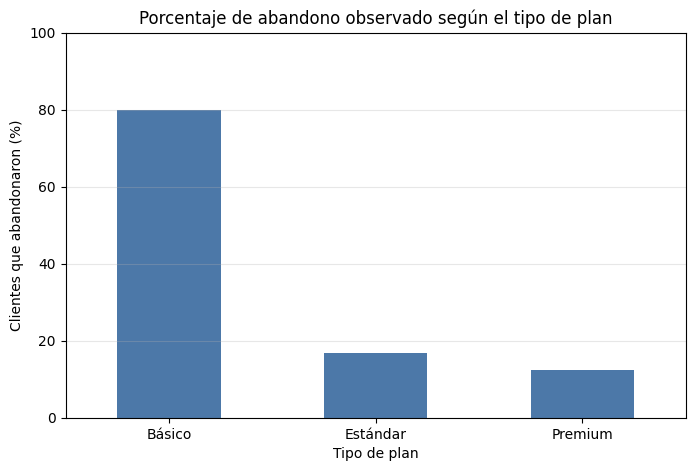

In [13]:
abandono_por_plan["Sí"].plot(
    kind="bar",
    color="#4C78A8",
    figsize=(8, 5)
)

plt.title("Porcentaje de abandono observado según el tipo de plan")
plt.xlabel("Tipo de plan")
plt.ylabel("Clientes que abandonaron (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.show()

En estos datos, el plan Básico presenta un porcentaje de abandono mayor que los otros planes. Eso convierte a `tipo_plan` en una variable razonable para investigar, pero no prueba que el plan sea la causa del abandono ni que la relación se mantenga en otros clientes.

La utilidad predictiva deberá comprobarse más adelante con una evaluación adecuada. En este capítulo solo buscamos variables que tengan sentido, muestren alguna señal y estén disponibles en el momento correcto.

## 7. Revisar cuándo está disponible cada dato

Una relación fuerte con el objetivo no alcanza para aceptar una variable. También necesitamos reconstruir la línea temporal del problema: qué sabemos al finalizar el mes actual y qué conocemos recién después.

In [14]:
disponibilidad = pd.DataFrame({
    "columna": df.columns,
    "momento_disponible": [
        "Antes", "Antes", "Antes", "Antes", "Antes", "Antes",
        "Antes", "Antes", "Después", "Después", "Después"
    ],
    "decision": [
        "Excluir: identificador", "Puede integrar X", "Puede integrar X",
        "Puede integrar X", "Puede integrar X", "Puede integrar X",
        "Puede integrar X", "Puede integrar X", "Es y",
        "Excluir de X", "Excluir de X"
    ]
})

disponibilidad

,columna,momento_disponible,decision
0,cliente_id,Antes,Excluir: identificador
1,antiguedad_meses,Antes,Puede integrar X
2,uso_semanal_horas,Antes,Puede integrar X
3,reclamos_ultimos_3_meses,Antes,Puede integrar X
4,dias_desde_ultimo_acceso,Antes,Puede integrar X
5,tipo_plan,Antes,Puede integrar X
6,pago_automatico,Antes,Puede integrar X
7,canal_preferido,Antes,Puede integrar X
8,abandono_proximo_mes,Después,Es y
9,fecha_baja,Después,Excluir de X


Las siete variables elegidas para `X` están disponibles antes de la predicción. `abandono_proximo_mes` se conoce después y funciona como `y`. La fecha y el motivo de baja también se conocen después, pero no son objetivos del proyecto: son consecuencias del resultado y deben excluirse.

El identificador sí existe antes, pero queda afuera por otra razón: permite ubicar al cliente, no describir un patrón que esperemos generalizar.

## 8. Detectar una fuga de datos

Imaginemos que seleccionamos todas las columnas excepto el target y el identificador. En ese caso incluiríamos `fecha_baja` y `motivo_baja`. El código funcionaría, pero la decisión sería incorrecta.

Veamos qué relación tiene la existencia de una fecha de baja con la variable objetivo.

In [15]:
tiene_fecha_baja = df["fecha_baja"].notna().map({True: "Sí", False: "No"})

pd.crosstab(
    tiene_fecha_baja,
    y,
    rownames=["Tiene fecha de baja"],
    colnames=["Abandono próximo mes"]
)

Abandono próximo mes,No,Sí
Tiene fecha de baja,,
No,14,0
Sí,0,10


La tabla muestra una coincidencia total: todos los clientes con fecha de baja pertenecen a la clase `Sí`, y todos los que no tienen fecha pertenecen a la clase `No`.

Esta relación parece extremadamente útil, pero es engañosa. La fecha se registra cuando el abandono ya ocurrió. Un sistema que intente anticiparlo al finalizar el mes actual todavía no dispondrá de ese dato. Incluirla en `X` sería una fuga de datos: el modelo recibiría una parte de la respuesta que intentamos predecir.

La misma columna podría ser útil para otro análisis, por ejemplo estudiar bajas ya ocurridas. El problema aparece cuando la usamos para anticipar una baja futura.

In [16]:
columnas_incorrectas = columnas_entrada + ["fecha_baja", "motivo_baja"]

comparacion_selecciones = pd.DataFrame({
    "seleccion": ["X incorrecta", "X válida"],
    "cantidad_columnas": [len(columnas_incorrectas), len(columnas_entrada)],
    "incluye_informacion_posterior": ["Sí", "No"]
})

comparacion_selecciones

,seleccion,cantidad_columnas,incluye_informacion_posterior
0,X incorrecta,9,Sí
1,X válida,7,No


La selección incorrecta tiene más columnas, pero no es mejor. Agregar información puede perjudicar la validez del proyecto si esa información no estará disponible en el uso real.

La fuga de datos no siempre produce un error de Python. Por eso, para detectarla necesitamos conocer el significado de las columnas y el momento en que se generan.

## 9. Construir la selección final

Después de revisar el objetivo, el tipo de las variables y su disponibilidad temporal, podemos construir la versión final de `X` e `y`.

In [17]:
X_final = df[columnas_entrada].copy()
y_final = df["abandono_proximo_mes"].copy()

pd.concat(
    [X_final.head(), y_final.head()],
    axis=1
)

,antiguedad_meses,uso_semanal_horas,reclamos_ultimos_3_meses,dias_desde_ultimo_acceso,tipo_plan,pago_automatico,canal_preferido,abandono_proximo_mes
0,36,9.2,0,2,Premium,Sí,App,No
1,4,1.4,3,24,Básico,No,Teléfono,Sí
2,18,6.8,1,5,Estándar,Sí,Web,No
3,2,0.8,4,31,Básico,No,Teléfono,Sí
4,48,10.5,0,1,Premium,Sí,App,No


La tabla vuelve a mostrar juntas las entradas y la respuesta para que podamos verificar su correspondencia, pero en el código quedaron almacenadas por separado.

La selección es conceptualmente válida para el problema planteado: `X_final` contiene datos disponibles antes de predecir y `y_final` contiene la respuesta histórica. Esto no significa que las variables ya estén completamente preparadas para cualquier modelo. Las categorías, los valores faltantes y otras transformaciones se trabajarán más adelante.

## Actividad breve

Probá modificar la lista `columnas_actividad`. Tu objetivo es conservar solamente columnas que puedan funcionar como entradas válidas. Después ejecutá la celda y compará tu selección con `columnas_entrada`.

In [18]:
columnas_actividad = [
    "antiguedad_meses",
    "uso_semanal_horas",
    "reclamos_ultimos_3_meses",
    "dias_desde_ultimo_acceso",
    "tipo_plan",
    "pago_automatico",
    "canal_preferido",
]

X_actividad = df[columnas_actividad]

print("Columnas seleccionadas:")
print(X_actividad.columns.tolist())
print(
    "\n¿Coinciden con la selección válida?:",
    set(columnas_actividad) == set(columnas_entrada)
)

Columnas seleccionadas:
['antiguedad_meses', 'uso_semanal_horas', 'reclamos_ultimos_3_meses', 'dias_desde_ultimo_acceso', 'tipo_plan', 'pago_automatico', 'canal_preferido']

¿Coinciden con la selección válida?: True


Si agregás `cliente_id`, `fecha_baja`, `motivo_baja` o `abandono_proximo_mes`, la selección dejará de coincidir con la propuesta válida. Las razones no son idénticas: una es un identificador, dos contienen información posterior y la última es el target.

## Cierre del cuaderno

En este cuaderno separamos un DataFrame en variables de entrada y variable objetivo. Vimos que `X` no debe construirse tomando todas las columnas disponibles: cada feature necesita una justificación vinculada con el problema, su significado y el momento en que estará disponible.

También distinguimos variables numéricas, categóricas e identificadores. Observamos algunas relaciones con el abandono, pero evitamos confundir asociación con causalidad o con utilidad predictiva ya demostrada.

Finalmente, detectamos una fuga de datos. `fecha_baja` y `motivo_baja` revelaban información posterior al resultado y podían producir una impresión engañosa de facilidad. La selección final quedó organizada, pero todavía no dividimos los datos ni transformamos sus columnas: esos pasos tendrán su propio desarrollo.

## Para pensar

Antes de continuar, respondé con tus propias palabras:

1. ¿Qué diferencia hay entre la información almacenada en `X` y la almacenada en `y`?
2. ¿Por qué `cliente_id` no es una buena variable predictora aunque esté guardada como número?
3. ¿Qué diferencia hay entre el tipo con el que `pandas` almacena una columna y su tipo conceptual?
4. ¿Por qué una relación clara con el target no alcanza para aceptar una variable como feature?
5. ¿Qué pregunta temporal ayuda a detectar una posible fuga de datos?
6. ¿Por qué una selección con más columnas puede ser peor que otra con menos columnas?